# Sesión conjunta · ¿Cuántas neuronas responden?
### L6 · viernes 18 de septiembre

Hoy calculamos, todos juntos, **la fracción de neuronas de su área que responden a las rejillas en
movimiento**. Es el único número que las once parejas van a calcular igual, y es el que vamos a
poner lado a lado el día de los pósters.

**Esto no es tarea.** Sale de esta sesión hecho. Pero debe incluirse en el notebook del proyecto final, y el resultado en el poster.

## Cómo se usa este notebook

Cada paso tiene dos celdas:

- Una **celda de texto con viñetas**: eso es lo que la celda de código tiene que hacer. Conviértanlo
  en un prompt, pídanle el código al modelo, péguenlo abajo y córranlo.
- Una **celda de código vacía**: ahí va lo que les devolvió, ya revisado.

Al final de cada paso hay una línea de **cómo saber si quedó bien**. Úsenla siempre. El modelo
escribe código que corre y da números equivocados sin avisar, y esa es la única defensa que tienen.

## Un consejo que les va a ahorrar tiempo

Cuando le pidan el código de los Pasos 2 en adelante, **péguenle primero la salida del paso 1**, la lista de variables del
archivo. Si el modelo no sabe cómo está hecho el archivo, se lo inventa: va a suponer nombres de
columnas que no existen y el código va a fallar o, peor, va a correr sobre lo que no es.

---
## Descargar los datos

Esta celda ya está escrita. Lo único que cambian es `MI_AREA`.

In [ ]:
!pip install gdown -q
import numpy as np, gdown

# ---- Los ocho archivos. Cambien MI_AREA por la que les tocó en el sorteo. ----
IDS = {
    "VISp": "17-YMZMNfKXKYUK-vtPEPETfpUP0iHHut",    # 382 neuronas
    "VISl": "1GqceDf_3YPgPWAbDsIrjQySj4DRsd8Tw",    # 277 neuronas
    "VISal": "1TTyTRj92kbf7H6KE5-ah0DT7Ho2pV1pC",   # 481 neuronas
    "VISrl": "1n5XdMa5ZvRcKu7eTuI8latBQt5EHkLjJ",   # 308 neuronas
    "VISam": "1ODzh0cs3p_YE1FYwvET1qeRNxU1hqFbO",   # 368 neuronas
    "VISpm": "1kL7fnRaB5tYVrNoabMGTqJzHnz8GWl_z",   # 296 neuronas
    "LGd": "1ClWjSlBLWNbpVKKF3Kf5QpOwTtE0Wa2_",     # 301 neuronas
    "LP": "1P7GMFi7u4cy_3AApazkyuovTKf4IFou0",      # 431 neuronas
}

MI_AREA = "VISpm"        # <<<<<<<<<<  CAMBIEN ESTO

gdown.download(id=IDS[MI_AREA], output="datos.npz", quiet=False)
d = np.load("datos.npz", allow_pickle=False)
print("\nÁrea:", MI_AREA, " ·  variables del archivo:")
print(d.files)

Downloading...
From: https://drive.google.com/uc?id=1kL7fnRaB5tYVrNoabMGTqJzHnz8GWl_z
To: /content/datos.npz
100%|██████████| 17.3M/17.3M [00:00<00:00, 125MB/s]


Área: VISpm  ·  variables del archivo:
['area', 'fuente', 'filtro', 'u_id', 'u_raton', 'u_canal', 'u_profundidad', 'u_snr', 'u_amplitude_cutoff', 'u_presence_ratio', 'u_isi_violations', 'u_firing_rate', 'u_onda', 'e_clase', 'e_raton', 'e_t0', 'e_dur', 'e_orientacion', 'e_frec_temporal', 'e_frec_espacial', 'e_contraste', 'e_color', 'e_imagen', 's_unidad', 's_ensayo', 's_t']


---
## PASO 1 · Ver qué hay en el archivo

Lo que tiene que hacer la celda de abajo:

- Cuántas neuronas hay en total
- Cuántos ratones distintos (la columna u_raton)
- Cuántos ensayos hay de cada clase de estímulo (la columna e_clase)
- Cuántos PAs hay en total

> **Cómo saber si quedó bien.** El número de neuronas tiene que coincidir con el de la tabla del enunciado, y los ratones tienen que ser 5. Si no, están cargando el archivo equivocado.

In [ ]:
# Número total de neuronas
n_neuronas = len(np.unique(d["u_id"]))

# Número de ratones distintos
n_ratones = len(np.unique(d["u_raton"]))

# Número de ensayos de cada clase de estímulo
clases = np.unique(d["e_clase"])

print("Área:", MI_AREA)
print("Número total de neuronas:", n_neuronas)
print("Número de ratones:", n_ratones)

print("\nEnsayos por clase de estímulo:")
for clase in clases:
    n_ensayos = np.sum(d["e_clase"] == clase)
    print(f"  {clase}: {n_ensayos}")

# Número total de PAs
n_pas = len(d["s_t"])

print("\nNúmero total de PAs:", n_pas)

Área: VISpm
Número total de neuronas: 296
Número de ratones: 5

Ensayos por clase de estímulo:
  drifting_gratings: 2000
  flashes: 750
  natural_movie_one: 40
  natural_scenes: 2000
  spontaneous: 750
  static_gratings: 1250

Número total de PAs: 4333522


---
## PASO 2 · Separar los ensayos que nos interesan

Lo que tiene que hacer la celda de abajo:

- Los índices de los ensayos cuya clase es drifting_gratings, que son las rejillas en movimiento
- Los índices de los ensayos cuya clase es spontaneous, que es la pantalla gris sin estímulo
- Imprimir cuántos hay de cada uno

> **Cómo saber si quedó bien.** Deben salir unos 2000 ensayos de rejillas y unos 750 de espontáneo, que son 400 y 150 por cada uno de los 5 ratones.

In [ ]:
# Índices de los ensayos de cada clase
indices_drifting = np.where(d["e_clase"] == "drifting_gratings")[0]
indices_spontaneous = np.where(d["e_clase"] == "spontaneous")[0]


# Imprimir cuántos hay de cada uno
print("drifting_gratings:", len(indices_drifting))
print("spontaneous:", len(indices_spontaneous))

drifting_gratings: 2000
spontaneous: 750


---
## PASO 3 · La tasa de disparo de cada neurona en cada ensayo

Lo que tiene que hacer la celda de abajo:

- Para cada neurona y cada ensayo de rejilla, contar los PAs que caen entre 0 y 2 segundos y dividir por 2. Eso es la tasa evocada, en hercios
- Hacer lo mismo con los ensayos de espontáneo, también entre 0 y 2 segundos. Esa es la tasa basal
- Guardar las dos como matrices con una fila por neurona y una columna por ensayo
- Importante para el prompt: s_unidad dice a qué neurona pertenece cada PA y s_ensayo a qué ensayo, y los dos son ÍNDICES de las tablas u_ y e_, no identificadores
- Y esto también, o el resultado sale mal sin avisar: la tabla de ensayos trae los CINCO RATONES JUNTOS, y cada neurona solo vio los ensayos de SU ratón. Hay que emparejar u_raton con e_raton y quedarse, para cada neurona, solo con sus propias columnas

> **Cómo saber si quedó bien.** La tasa evocada mediana tiene que estar entre 1 y 30 Hz. Si les da 0, casi seguro no emparejaron los ratones: están promediando cada neurona sobre 2000 ensayos cuando solo vio 400, y los otros 1600 son ceros que no significan nada.

In [ ]:
# --------------------------------------------------
# Datos
# --------------------------------------------------

u_raton = d["u_raton"]
e_raton = d["e_raton"]
e_clase = d["e_clase"]

s_unidad = d["s_unidad"]
s_ensayo = d["s_ensayo"]
s_t = d["s_t"]


# --------------------------------------------------
# Índices globales de los ensayos
# --------------------------------------------------

indices_drifting = np.where(e_clase == "drifting_gratings")[0]
indices_spontaneous = np.where(e_clase == "spontaneous")[0]


# --------------------------------------------------
# Número de neuronas
# --------------------------------------------------

n_neuronas = len(u_raton)


# --------------------------------------------------
# Crear matrices
# Cada neurona tiene 400 ensayos de drifting
# y 150 ensayos de spontaneous
# --------------------------------------------------

tasa_evocada = np.zeros((n_neuronas, 400))
tasa_basal = np.zeros((n_neuronas, 150))


# --------------------------------------------------
# Calcular tasas
# --------------------------------------------------

for i in range(n_neuronas):

    # Ratón de la neurona
    raton = u_raton[i]

    # Ensayos del mismo ratón
    ensayos_drifting = indices_drifting[
        e_raton[indices_drifting] == raton
    ]

    ensayos_spontaneous = indices_spontaneous[
        e_raton[indices_spontaneous] == raton
    ]

    # PAs de esta neurona
    mask_neurona = (s_unidad == i)

    tiempos = s_t[mask_neurona]
    ensayos = s_ensayo[mask_neurona]

    # Solo PAs entre 0 y 2 segundos
    mask_tiempo = (tiempos >= 0) & (tiempos <= 2)

    ensayos = ensayos[mask_tiempo]

    # Contar PAs de cada ensayo
    conteo = np.bincount(
        ensayos,
        minlength=len(e_clase)
    )

    # Tasa evocada
    tasa_evocada[i, :] = conteo[ensayos_drifting] / 2

    # Tasa basal
    tasa_basal[i, :] = conteo[ensayos_spontaneous] / 2


# --------------------------------------------------
# Comprobaciones
# --------------------------------------------------

print("Número de neuronas:", n_neuronas)
print("Forma tasa evocada:", tasa_evocada.shape)
print("Forma tasa basal:", tasa_basal.shape)

print("\nMediana de la tasa evocada:",
      np.median(tasa_evocada), "Hz")
import pandas as pd
from IPython.display import display

# =========================
# TABLA DE NEURONAS: u_
# =========================

# Tomamos solamente las variables u_ que son vectores de una dimensión
u_cols = [
    x for x in d.files
    if x.startswith("u_") and d[x].ndim == 1
]

tabla_u = pd.DataFrame({
    col: d[col]
    for col in u_cols
})

print("TABLA u_ — Información de las neuronas")
display(tabla_u.head(10))


# =========================
# TABLA DE ENSAYOS: e_
# =========================

e_cols = [
    x for x in d.files
    if x.startswith("e_") and d[x].ndim == 1
]

tabla_e = pd.DataFrame({
    col: d[col]
    for col in e_cols
})

print("TABLA e_ — Información de los ensayos")
display(tabla_e.head(10))


# =========================
# TABLA DE POTENCIALES DE ACCIÓN: s_
# =========================

s_cols = [
    x for x in d.files
    if x.startswith("s_") and d[x].ndim == 1
]

tabla_s = pd.DataFrame({
    col: d[col]
    for col in s_cols
})

print("TABLA s_ — Información de los potenciales de acción")
display(tabla_s.head(10))

Número de neuronas: 296
Forma tasa evocada: (296, 400)
Forma tasa basal: (296, 150)

Mediana de la tasa evocada: 2.5 Hz
TABLA u_ — Información de las neuronas


,u_id,u_raton,u_canal,u_profundidad,u_snr,u_amplitude_cutoff,u_presence_ratio,u_isi_violations,u_firing_rate
0,951820547,756029989,850121734,2240.0,2.255190,0.015591,0.99,0.002930,6.206446
1,951820541,756029989,850121734,2240.0,2.153555,0.017121,0.99,0.000000,1.828377
2,951820551,756029989,850121736,2260.0,3.488433,0.000759,0.99,0.000494,44.501192
3,951820565,756029989,850121740,2280.0,2.254929,0.085447,0.99,0.039871,4.121302
4,951820595,756029989,850121746,2300.0,3.889971,0.000015,0.99,0.038766,1.706318
5,951820631,756029989,850121756,2360.0,3.450713,0.005824,0.99,0.006211,22.286631
6,951820623,756029989,850121756,2360.0,2.352246,0.070084,0.99,0.180560,4.402058
7,951820670,756029989,850121764,2400.0,3.204998,0.040573,0.99,0.159575,6.199218
8,951821635,756029989,850121770,2420.0,2.453873,0.008735,0.97,0.000000,0.155585
9,951820713,756029989,850121770,2420.0,3.667444,0.000010,0.96,0.005471,2.622264


TABLA e_ — Información de los ensayos


,e_clase,e_raton,e_t0,e_dur,e_orientacion,e_frec_temporal,e_frec_espacial,e_contraste,e_color,e_imagen
0,drifting_gratings,756029989,1588.736891,2.00168,135.0,2.0,0.04,0.8,NaN,NaN
1,drifting_gratings,756029989,1591.739398,2.00168,180.0,2.0,0.04,0.8,NaN,NaN
2,drifting_gratings,756029989,1594.741921,2.00167,270.0,2.0,0.04,0.8,NaN,NaN
3,drifting_gratings,756029989,1597.744458,2.00163,135.0,4.0,0.04,0.8,NaN,NaN
4,drifting_gratings,756029989,1600.746921,2.00168,135.0,2.0,0.04,0.8,NaN,NaN
5,drifting_gratings,756029989,1609.754498,2.00167,0.0,4.0,0.04,0.8,NaN,NaN
6,drifting_gratings,756029989,1615.759518,2.00168,180.0,15.0,0.04,0.8,NaN,NaN
7,drifting_gratings,756029989,1624.767031,2.00166,135.0,1.0,0.04,0.8,NaN,NaN
8,drifting_gratings,756029989,1633.774548,2.00170,45.0,4.0,0.04,0.8,NaN,NaN
9,drifting_gratings,756029989,1639.779548,2.00172,90.0,4.0,0.04,0.8,NaN,NaN


TABLA s_ — Información de los potenciales de acción


,s_unidad,s_ensayo,s_t
0,0,974,1.066064
1,0,411,0.597942
2,0,411,1.077310
3,0,413,0.056436
4,0,418,0.410063
5,0,420,0.355159
6,0,421,0.315306
7,0,422,1.086161
8,0,431,0.588008
9,0,440,1.046855


In [ ]:
print("Orientaciones:")
print(np.unique(d["e_orientacion"]))

print("\nFrecuencias temporales:")
print(np.unique(d["e_frec_temporal"]))

print("\nFrecuencias espaciales:")
print(np.unique(d["e_frec_espacial"]))

print("\nClases de ensayo:")
print(np.unique(d["e_clase"]))

Orientaciones:
[  0.  30.  45.  60.  90. 120. 135. 150. 180. 225. 270. 315.  nan]

Frecuencias temporales:
[ 1.  2.  4.  8. 15. nan]

Frecuencias espaciales:
[0.02 0.04 0.08 0.16 0.32  nan]

Clases de ensayo:
['drifting_gratings' 'flashes' 'natural_movie_one' 'natural_scenes'
 'spontaneous' 'static_gratings']


## Descripción de las tablas del conjunto de datos

El conjunto de datos está dividido en tres tablas principales: `u_`, `e_` y `s_`. Cada una contiene información diferente sobre las neuronas, los ensayos experimentales y los potenciales de acción registrados.

### Tabla `u_`: información de las neuronas

La tabla `u_` contiene información sobre las **296 neuronas** registradas en el área visual `VISpm`. Cada fila representa una neurona diferente.

- **`u_id`**: identificador único de la neurona.
- **`u_raton`**: identificador del ratón al que pertenece la neurona. Permite relacionar cada neurona con los ensayos realizados en ese mismo ratón.
- **`u_canal`**: identificador del canal de registro donde se detectó la neurona.
- **`u_profundidad`**: profundidad del canal o de la neurona dentro del tejido, expresada en µm.
- **`u_snr`**: relación señal/ruido (Signal-to-Noise Ratio), que indica qué tan distinguible es la señal neuronal respecto al ruido.
- **`u_amplitude_cutoff`**: estimación de la fracción de potenciales de acción que podrían no haber sido detectados debido a su baja amplitud.
- **`u_presence_ratio`**: proporción del tiempo de registro durante el cual la neurona estuvo presente y pudo ser detectada.
- **`u_isi_violations`**: proporción de violaciones del intervalo entre potenciales de acción (ISI), utilizada como indicador de la calidad de la unidad neuronal.
- **`u_firing_rate`**: frecuencia de disparo promedio de la neurona, expresada en Hz.

Por ejemplo, la primera fila corresponde a una neurona con `u_id = 951820547`, perteneciente al ratón `756029989`, registrada en el canal `850121734` y a una profundidad de 2240 µm.

---

### Tabla `e_`: información de los ensayos

La tabla `e_` contiene información sobre los **ensayos experimentales** realizados. Cada fila representa un ensayo y describe las características del estímulo presentado durante ese ensayo.

- **`e_clase`**: tipo de ensayo experimental. En este conjunto aparecen principalmente `drifting_gratings` y `spontaneous`.
- **`e_raton`**: identificador del ratón en el que se realizó el ensayo. Esta variable permite relacionar los ensayos con las neuronas de la tabla `u_`.
- **`e_t0`**: tiempo de inicio del ensayo dentro del registro.
- **`e_dur`**: duración del ensayo, aproximadamente 2 segundos para los ensayos mostrados.
- **`e_orientacion`**: orientación del estímulo visual, expresada en grados.
- **`e_frec_temporal`**: frecuencia temporal del estímulo, expresada en Hz.
- **`e_frec_espacial`**: frecuencia espacial del estímulo.
- **`e_contraste`**: contraste del estímulo visual.
- **`e_color`**: información relacionada con el color del estímulo, cuando está disponible.
- **`e_imagen`**: información sobre la imagen utilizada en el ensayo, cuando está disponible.

Por ejemplo, el primer ensayo corresponde a un `drifting_gratings` realizado en el ratón `756029989`, con una duración de aproximadamente 2 segundos, una orientación de 135°, una frecuencia temporal de 2 Hz, una frecuencia espacial de 0.04 y un contraste de 0.8.

---

### Tabla `s_`: información de los potenciales de acción

La tabla `s_` contiene información sobre los **potenciales de acción (spikes)** detectados durante los experimentos. Cada fila representa un potencial de acción individual.

- **`s_unidad`**: indica a qué neurona pertenece el potencial de acción. Este valor funciona como un índice que permite relacionarlo con una fila de la tabla `u_`.
- **`s_ensayo`**: indica durante qué ensayo ocurrió el potencial de acción. Este valor funciona como un índice que permite relacionarlo con una fila de la tabla `e_`.
- **`s_t`**: indica el momento en el que ocurrió el potencial de acción dentro del ensayo, expresado en segundos.

Por ejemplo, una fila con `s_unidad = 0`, `s_ensayo = 974` y `s_t = 1.066064` indica que el potencial de acción pertenece a la neurona ubicada en el índice 0 de la tabla `u_`, ocurrió durante el ensayo ubicado en el índice 974 de la tabla `e_` y ocurrió aproximadamente 1.07 segundos después del inicio del ensayo.

### Relación entre las tres tablas

Las tres tablas están conectadas entre sí:

**`u_` (neuronas) ← `s_unidad` → `s_` (potenciales de acción) ← `s_ensayo` → `e_` (ensayos)**

De esta manera, podemos determinar **qué neurona produjo cada potencial de acción, en qué ensayo ocurrió y qué estímulo estaba siendo presentado durante ese ensayo**.

Además, `u_raton` y `e_raton` permiten asegurar que una neurona se compare únicamente con los ensayos realizados en el mismo ratón. Esta relación es importante para calcular correctamente las tasas de disparo evocadas y basales.


--
## PASO 4 · ¿Cuáles responden?

Lo que tiene que hacer la celda de abajo:

- Para cada neurona, el Z-score: la tasa evocada promedio menos la basal promedio, dividido por la desviación estándar de su propia basal. Todo calculado solo sobre los ensayos de su ratón
- Calcula la respuesta evocada para cada una de las combinaciones de caracteristica de estímulo posibles (direcciones, frecuencias temporales, frecuencias espaciales).
- Identifica la combinación que genera la tasa de disparo máxima (condición preferida) para cada neurona y calcula el z-score usando solo los ensayos de esta combinación.
- Contar cuántas neuronas tienen un Z-score de 2,5 o más
- La fracción respondedora es ese número dividido por el total de neuronas
- Imprimir la fracción como porcentaje

> **Cómo saber si quedó bien.** Si les da 0 % o más del 95 %, revisen el paso 3 antes de seguir: casi siempre es que no emparejaron los ratones. Cualquier cosa entre esos dos extremos es un resultado, no un error. En VISp, con umbral 2,5, da alrededor del 13 % si combinan todas las características del estímulo.

In [ ]:
import numpy as np

# ============================================================
# 1. Cargar datos
# ============================================================

u_raton = d["u_raton"]
e_raton = d["e_raton"]
e_clase = d["e_clase"]

e_orientacion = d["e_orientacion"]
e_frec_temporal = d["e_frec_temporal"]
e_frec_espacial = d["e_frec_espacial"]

s_unidad = d["s_unidad"]
s_ensayo = d["s_ensayo"]
s_t = d["s_t"]


# ============================================================
# 2. Identificar ensayos drifting y spontaneous
# ============================================================

indices_drifting = np.where(
    e_clase == "drifting_gratings"
)[0]

indices_spontaneous = np.where(
    e_clase == "spontaneous"
)[0]


# ============================================================
# 3. Calcular Z-score de cada neurona
# ============================================================

z_scores = np.full(len(u_raton), np.nan)

# Guardaremos además la combinación preferida
preferencias = []


for i in range(len(u_raton)):

    # --------------------------------------------------------
    # Ratón de la neurona
    # --------------------------------------------------------

    raton = u_raton[i]


    # --------------------------------------------------------
    # Ensayos de drifting de ESTE ratón
    # --------------------------------------------------------

    ensayos_drifting = indices_drifting[
        e_raton[indices_drifting] == raton
    ]

    # Ensayos espontáneos de ESTE ratón
    ensayos_spontaneous = indices_spontaneous[
        e_raton[indices_spontaneous] == raton
    ]


    # --------------------------------------------------------
    # Spikes de esta neurona
    # --------------------------------------------------------

    mask_neurona = s_unidad == i

    ensayos_spikes = s_ensayo[mask_neurona]
    tiempos_spikes = s_t[mask_neurona]


    # Solo spikes entre 0 y 2 segundos
    mask_tiempo = (
        (tiempos_spikes >= 0) &
        (tiempos_spikes <= 2)
    )

    ensayos_spikes = ensayos_spikes[mask_tiempo]


    # Contar spikes por ensayo
    conteo_spikes = np.bincount(
        ensayos_spikes,
        minlength=len(e_clase)
    )


    # ========================================================
    # 4. Buscar la combinación preferida
    # ========================================================

    tasas_combinaciones = []
    combinaciones = []


    for ensayo in ensayos_drifting:

        # Características del estímulo
        orientacion = e_orientacion[ensayo]
        frec_temporal = e_frec_temporal[ensayo]
        frec_espacial = e_frec_espacial[ensayo]

        # Ignorar valores NaN
        if (
            np.isnan(orientacion) or
            np.isnan(frec_temporal) or
            np.isnan(frec_espacial)
        ):
            continue

        combinacion = (
            orientacion,
            frec_temporal,
            frec_espacial
        )

        combinaciones.append(combinacion)


    # Si no hay combinaciones, pasar a la siguiente neurona
    if len(combinaciones) == 0:
        continue


    # Eliminar combinaciones repetidas
    combinaciones_unicas = list(set(combinaciones))


    # --------------------------------------------------------
    # Calcular tasa promedio para cada combinación
    # --------------------------------------------------------

    for combinacion in combinaciones_unicas:

        orientacion, frec_temporal, frec_espacial = combinacion

        ensayos_combinacion = []

        for ensayo in ensayos_drifting:

            if (
                e_orientacion[ensayo] == orientacion and
                e_frec_temporal[ensayo] == frec_temporal and
                e_frec_espacial[ensayo] == frec_espacial
            ):
                ensayos_combinacion.append(ensayo)

        if len(ensayos_combinacion) == 0:
            continue

        # Tasa de disparo de cada ensayo
        tasas = (
            conteo_spikes[ensayos_combinacion] / 2
        )

        tasa_promedio = np.mean(tasas)

        tasas_combinaciones.append(tasa_promedio)


    # Si no se pudo calcular ninguna combinación
    if len(tasas_combinaciones) == 0:
        continue


    # ========================================================
    # 5. Encontrar la combinación preferida
    # ========================================================

    indice_maximo = np.argmax(tasas_combinaciones)

    combinacion_preferida = combinaciones_unicas[indice_maximo]

    tasa_preferida = tasas_combinaciones[indice_maximo]


    # Guardar combinación preferida
    preferencias.append(
        (
            i,
            combinacion_preferida,
            tasa_preferida
        )
    )


    # ========================================================
    # 6. Respuesta evocada en la condición preferida
    # ========================================================

    orientacion, frec_temporal, frec_espacial = combinacion_preferida

    ensayos_preferidos = []

    for ensayo in ensayos_drifting:

        if (
            e_orientacion[ensayo] == orientacion and
            e_frec_temporal[ensayo] == frec_temporal and
            e_frec_espacial[ensayo] == frec_espacial
        ):
            ensayos_preferidos.append(ensayo)


    tasas_preferidas = (
        conteo_spikes[ensayos_preferidos] / 2
    )

    media_evocada = np.mean(tasas_preferidas)


    # ========================================================
    # 7. Respuesta basal
    # ========================================================

    tasas_basales = (
        conteo_spikes[ensayos_spontaneous] / 2
    )

    media_basal = np.mean(tasas_basales)

    desviacion_basal = np.std(
        tasas_basales,
        ddof=1
    )


    # ========================================================
    # 8. Z-score
    # ========================================================

    if desviacion_basal > 0:

        z_scores[i] = (
            media_evocada - media_basal
        ) / desviacion_basal


# ============================================================
# 9. Resultado final
# ============================================================

respondedoras = np.sum(
    z_scores >= 2.5
)

fraccion = (
    respondedoras / len(u_raton)
)

porcentaje = fraccion * 100


print("Número total de neuronas:", len(u_raton))
print("Neuronas con Z-score >= 2.5:", respondedoras)
print("Fracción respondedora:", fraccion)
print("Porcentaje de neuronas respondedoras:", porcentaje, "%")

Número total de neuronas: 296
Neuronas con Z-score >= 2.5: 117
Fracción respondedora: 0.3952702702702703
Porcentaje de neuronas respondedoras: 39.52702702702703 %


---
## PASO 5 · La misma cuenta, ratón por ratón

Lo que tiene que hacer la celda de abajo:

- Repetir el paso 4 pero por separado para las neuronas de cada ratón, usando la columna u_raton
- Imprimir las cinco fracciones, con el número de neuronas de cada ratón


> **Cómo saber si quedó bien.** Las cinco se van a parecer pero no van a ser iguales. Esa diferencia entre animales es exactamente la razón por la que el bootstrap tiene que tener el nivel de ratón.

In [ ]:
# ============================================================
# Fracción de neuronas respondedoras por ratón
# ============================================================

ratones = np.unique(u_raton)

print("Fracción de neuronas respondedoras por ratón:\n")

for raton in ratones:

    # Neuronas pertenecientes a este ratón
    indices = np.where(u_raton == raton)[0]

    # Z-scores de esas neuronas
    z_raton = z_scores[indices]

    # Número total de neuronas del ratón
    n_neuronas = len(indices)

    # Número de neuronas con Z >= 2.5
    n_respondedoras = np.sum(z_raton >= 2.5)

    # Fracción
    fraccion = n_respondedoras / n_neuronas

    print(
        f"Ratón {raton}: "
        f"{n_respondedoras}/{n_neuronas} "
        f"= {fraccion:.3f}"
    )

Fracción de neuronas respondedoras por ratón:

Ratón 715093703: 26/51 = 0.510
Ratón 750749662: 15/65 = 0.231
Ratón 756029989: 40/94 = 0.426
Ratón 760345702: 23/45 = 0.511
Ratón 761418226: 13/41 = 0.317


---
## PASO 6 · La gráfica

Lo que tiene que hacer la celda de abajo:

- Un punto por ratón con su fracción respondedora
- Una línea horizontal con la fracción del conjunto de las neuronas
- Ejes rotulados y el número del conjunto escrito dentro de la figura
- Título con el nombre del área

> **Cómo saber si quedó bien.** Variación pequeña de cada ratón.

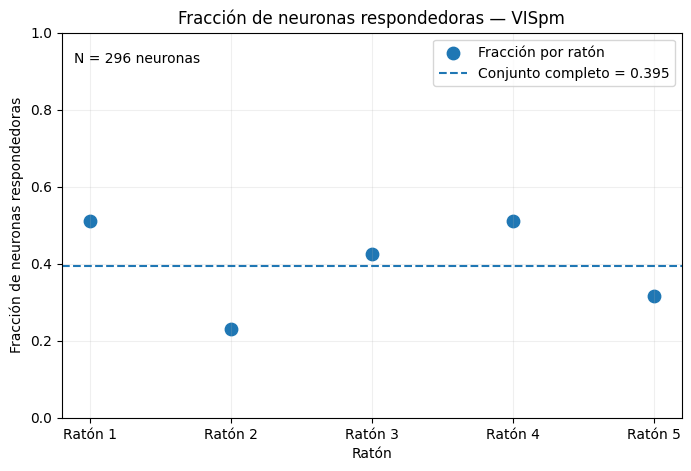

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Fracción respondedora de cada ratón
# ============================================================

ratones = np.unique(u_raton)

fracciones_ratones = []

for raton in ratones:

    # Índices de las neuronas de este ratón
    indices = np.where(u_raton == raton)[0]

    # Z-scores de sus neuronas
    z_raton = z_scores[indices]

    # Fracción con Z >= 2.5
    fraccion = np.mean(z_raton >= 2.5)

    fracciones_ratones.append(fraccion)


# ============================================================
# Fracción del conjunto completo
# ============================================================

fraccion_global = np.mean(z_scores >= 2.5)


# ============================================================
# Gráfica
# ============================================================

plt.figure(figsize=(8, 5))

# Un punto por ratón
plt.scatter(
    range(1, len(ratones) + 1),
    fracciones_ratones,
    s=80,
    label="Fracción por ratón"
)

# Línea horizontal: conjunto completo
plt.axhline(
    fraccion_global,
    linestyle="--",
    label=f"Conjunto completo = {fraccion_global:.3f}"
)

# Ejes
plt.xlabel("Ratón")
plt.ylabel("Fracción de neuronas respondedoras")

# Título
plt.title("Fracción de neuronas respondedoras — VISpm")

# Número del conjunto dentro de la figura
plt.text(
    0.02,
    0.95,
    f"N = {len(u_raton)} neuronas",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.xticks(
    range(1, len(ratones) + 1),
    [f"Ratón {i}" for i in range(1, len(ratones) + 1)]
)

plt.ylim(0, 1)
plt.grid(alpha=0.2)
plt.legend()

plt.show()

---
## Para cerrar

Anoten su número: **la fracción de neuronas de su área que responden a las rejillas en movimiento**.

Ese número va al póster y es el que comparamos entre las once parejas el viernes 25. Puestos en
orden de área, los once juntos reconstruyen la jerarquía visual del ratón.

Guarden este notebook en su repositorio de GitHub. Es la primera pieza del pipeline del proyecto.

## *A · PSTH poblacional de drifting gratings.*

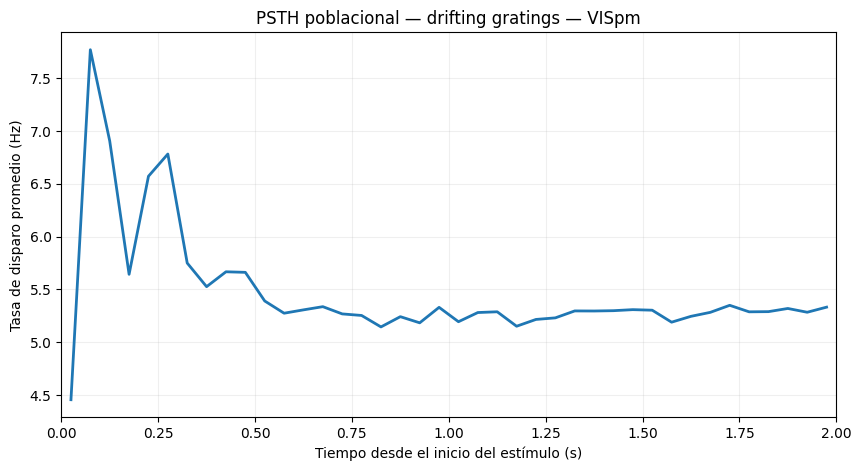

Área: VISpm
Número de neuronas: 296
Ensayos drifting: 2000
Bins temporales: 40
Tamaño del bin: 0.05 s
Rango del PSTH: 4.456 a 7.771 Hz


In [ ]:
# ============================================================
# PASO A · PSTH POBLACIONAL DE DRIFTING GRATINGS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Parámetros del PSTH
# ------------------------------------------------------------

duracion = 2.0
bin_size = 0.05  # 50 ms

bins = np.arange(
    0,
    duracion + bin_size,
    bin_size
)

tiempos = (bins[:-1] + bins[1:]) / 2


# ------------------------------------------------------------
# 2. Ensayos drifting
# ------------------------------------------------------------

indices_drifting = np.where(
    d["e_clase"] == "drifting_gratings"
)[0]


# ------------------------------------------------------------
# 3. Matriz para guardar el PSTH de cada neurona
#
# Filas    = neuronas
# Columnas = bins temporales
# ------------------------------------------------------------

psth_neuronas = np.zeros(
    (len(u_raton), len(bins) - 1)
)


# ------------------------------------------------------------
# 4. Calcular PSTH de cada neurona
# ------------------------------------------------------------

for i in range(len(u_raton)):

    # Ratón de la neurona
    raton = u_raton[i]

    # Ensayos drifting de SU ratón
    ensayos_drifting = indices_drifting[
        e_raton[indices_drifting] == raton
    ]

    # PAs de esta neurona
    mask_neurona = d["s_unidad"] == i

    ensayos_spikes = d["s_ensayo"][mask_neurona]
    tiempos_spikes = d["s_t"][mask_neurona]

    # Solo PAs de los ensayos de SU ratón
    # y entre 0 y 2 segundos
    mask = (
        np.isin(ensayos_spikes, ensayos_drifting)
        & (tiempos_spikes >= 0)
        & (tiempos_spikes <= duracion)
    )

    tiempos_spikes = tiempos_spikes[mask]

    # Contar PAs en cada bin temporal
    conteo_bins = np.histogram(
        tiempos_spikes,
        bins=bins
    )[0]

    # Convertir a Hz:
    # spikes / 400 ensayos / duración del bin
    psth_neuronas[i, :] = (
        conteo_bins
        / len(ensayos_drifting)
        / bin_size
    )


# ------------------------------------------------------------
# 5. Promedio de las neuronas
# ------------------------------------------------------------

psth_poblacional = np.mean(
    psth_neuronas,
    axis=0
)


# ------------------------------------------------------------
# 6. Graficar
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    tiempos,
    psth_poblacional,
    linewidth=2
)

plt.xlabel(
    "Tiempo desde el inicio del estímulo (s)"
)

plt.ylabel(
    "Tasa de disparo promedio (Hz)"
)

plt.title(
    "PSTH poblacional — drifting gratings — VISpm"
)

plt.xlim(0, 2)

plt.grid(alpha=0.2)

plt.show()


# ------------------------------------------------------------
# 7. Comprobaciones
# ------------------------------------------------------------

print("Área:", MI_AREA)
print("Número de neuronas:", len(u_raton))
print("Ensayos drifting:", len(indices_drifting))
print("Bins temporales:", len(bins) - 1)
print("Tamaño del bin:", bin_size, "s")

print(
    "Rango del PSTH:",
    round(np.min(psth_poblacional), 3),
    "a",
    round(np.max(psth_poblacional), 3),
    "Hz"
)

# PASO B — PSTH por clase de estímulo

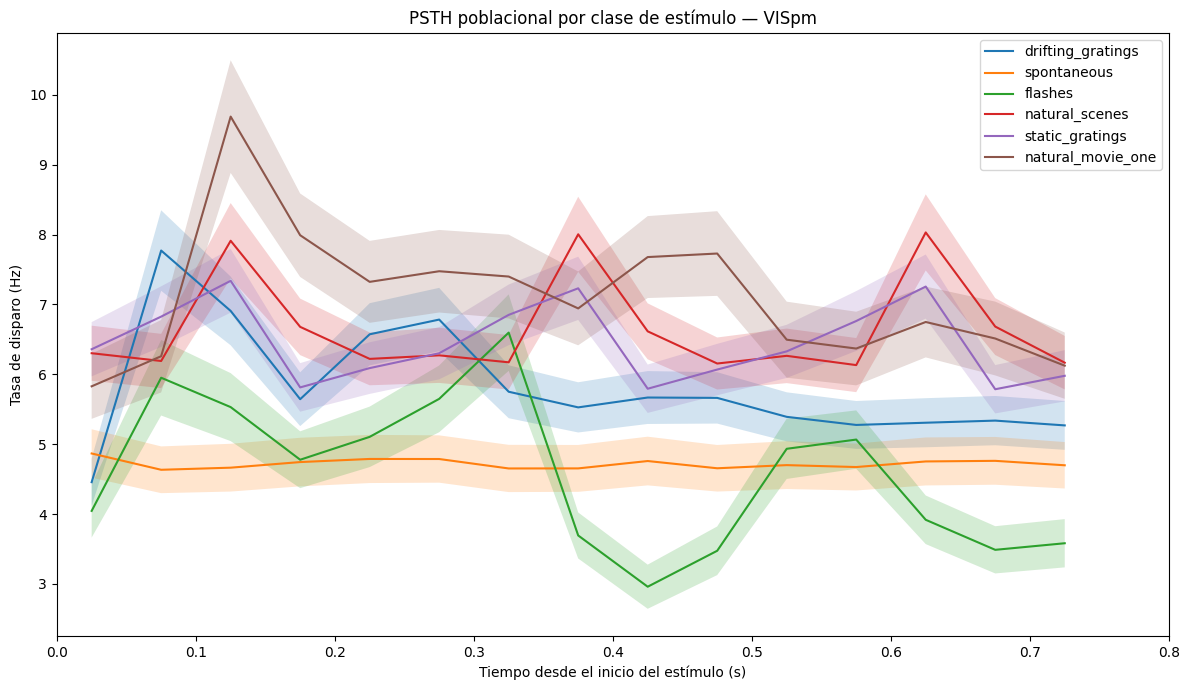

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. CARGAR LOS DATOS
# ============================================================

d = np.load("datos.npz", allow_pickle=False)

u_raton = d["u_raton"]
e_raton = d["e_raton"]
e_clase = d["e_clase"]
s_unidad = d["s_unidad"]
s_ensayo = d["s_ensayo"]
s_t = d["s_t"]

# ============================================================
# 2. CONFIGURACIÓN DEL PSTH
# ============================================================

duracion = 0.75
bin_size = 0.05

bins = np.arange(0, duracion + bin_size, bin_size)
tiempos = (bins[:-1] + bins[1:]) / 2

# Clases que queremos comparar
clases = [
    "drifting_gratings",
    "spontaneous",
    "flashes",
    "natural_scenes",
    "static_gratings",
    "natural_movie_one"
]

# ============================================================
# 3. CREAR LA FIGURA
# ============================================================

plt.figure(figsize=(12, 7))

# ============================================================
# 4. CALCULAR EL PSTH PARA CADA CLASE
# ============================================================

for clase in clases:

    # Ensayos pertenecientes a esta clase
    indices_ensayos = np.where(e_clase == clase)[0]

    # Matriz:
    # filas = neuronas
    # columnas = bins de tiempo
    psth_neuronas = np.zeros(
        (len(u_raton), len(bins) - 1)
    )

    # --------------------------------------------------------
    # Calcular PSTH de cada neurona
    # --------------------------------------------------------

    for i in range(len(u_raton)):

        # Ratón al que pertenece la neurona
        raton = u_raton[i]

        # Ensayos de esta clase que pertenecen al mismo ratón
        ensayos_raton = indices_ensayos[
            e_raton[indices_ensayos] == raton
        ]

        # Si el ratón no tiene ensayos de esta clase,
        # dejamos la neurona en cero
        if len(ensayos_raton) == 0:
            continue

        # Spikes pertenecientes a esta neurona
        mask_neurona = s_unidad == i

        ensayos_spikes = s_ensayo[mask_neurona]
        tiempos_spikes = s_t[mask_neurona]

        # Seleccionar únicamente los spikes:
        # 1. de los ensayos correctos
        # 2. entre 0 y 2 segundos
        mask = (
            np.isin(ensayos_spikes, ensayos_raton)
            & (tiempos_spikes >= 0)
            & (tiempos_spikes < duracion)
        )

        tiempos_seleccionados = tiempos_spikes[mask]

        # Contar spikes dentro de cada bin
        conteo_bins = np.histogram(
            tiempos_seleccionados,
            bins=bins
        )[0]

        # Convertir a Hz
        psth_neuronas[i, :] = (
            conteo_bins
            / len(ensayos_raton)
            / bin_size
        )

    # ========================================================
    # 5. PROMEDIO Y ERROR
    # ========================================================

    promedio = np.mean(
        psth_neuronas,
        axis=0
    )

    desviacion = np.std(
        psth_neuronas,
        axis=0,
        ddof=1
    )

    # Error estándar de la media
    sem = desviacion / np.sqrt(
        psth_neuronas.shape[0]
    )

    # ========================================================
    # 6. GRAFICAR LA CURVA
    # ========================================================

    plt.plot(
        tiempos,
        promedio,
        label=clase
    )

    # ========================================================
    # 7. SOMBRA DEL ERROR
    # ========================================================

    plt.fill_between(
        tiempos,
        promedio - sem,
        promedio + sem,
        alpha=0.20
    )

# ============================================================
# 8. FORMATO DE LA GRÁFICA
# ============================================================

plt.xlabel(
    "Tiempo desde el inicio del estímulo (s)"
)

plt.ylabel(
    "Tasa de disparo (Hz)"
)

plt.title(
    "PSTH poblacional por clase de estímulo — VISpm"
)

# IMPORTANTE:
# todas las curvas se muestran solamente entre 0 y 2 segundos
plt.xlim(0, 0.80)

plt.legend()

plt.tight_layout()

plt.show()

## C Heat map

In [ ]:
# ============================================================
# PASO C · IDENTIFICAR LAS CONDICIONES
# ============================================================

ensayos_drifting = np.where(
    d["e_clase"] == "drifting_gratings"
)[0]

condiciones = np.column_stack([
    e_orientacion[ensayos_drifting],
    e_frec_temporal[ensayos_drifting],
    e_frec_espacial[ensayos_drifting]
])

condiciones_unicas = np.unique(
    condiciones,
    axis=0
)

print("Número de condiciones únicas:",
      len(condiciones_unicas))

print("\nPrimeras condiciones:")
print(condiciones_unicas[:10])

Número de condiciones únicas: 135

Primeras condiciones:
[[0.0e+00 1.0e+00 4.0e-02]
 [0.0e+00 2.0e+00 4.0e-02]
 [0.0e+00 4.0e+00 4.0e-02]
 [0.0e+00 8.0e+00 4.0e-02]
 [0.0e+00 1.5e+01 4.0e-02]
 [4.5e+01 1.0e+00 4.0e-02]
 [4.5e+01 2.0e+00 4.0e-02]
 [4.5e+01 4.0e+00 4.0e-02]
 [4.5e+01 8.0e+00 4.0e-02]
 [4.5e+01 1.5e+01 4.0e-02]]


Condiciones movimiento: 40  | estática: 30
Z mínimo: -3.2166535053082854  Z máximo: 252.13427573671365


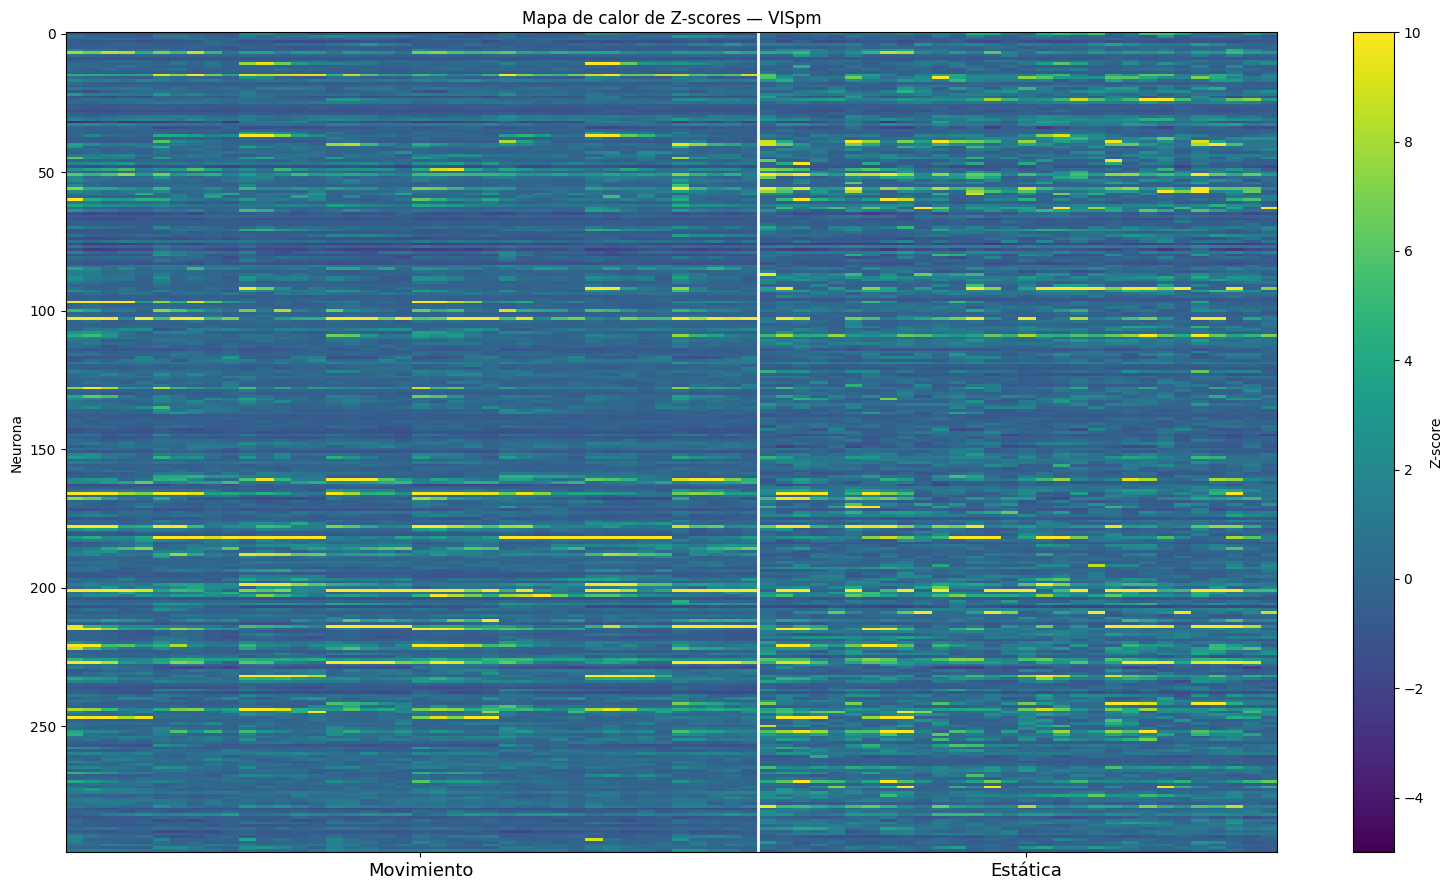

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

d = np.load("datos.npz", allow_pickle=False)

u_raton = d["u_raton"]
e_clase = d["e_clase"]
e_raton = d["e_raton"]
e_orientacion = d["e_orientacion"]
e_frec_temporal = d["e_frec_temporal"]
e_frec_espacial = d["e_frec_espacial"]
s_unidad = d["s_unidad"]
s_ensayo = d["s_ensayo"]
s_t = d["s_t"]

n_neuronas = len(u_raton)

def condiciones_validas(ensayos, columnas):
    """Devuelve ensayos y condiciones únicas, sin los barridos en blanco (NaN)."""
    vals = np.column_stack([col[ensayos] for col in columnas])
    mask = ~np.any(np.isnan(vals), axis=1)
    ensayos_ok = ensayos[mask]
    condiciones_ok = np.unique(vals[mask], axis=0)
    return ensayos_ok, condiciones_ok

# --- Movimiento (drifting gratings): orientación x frec. temporal ---
ensayos_drifting = np.where(e_clase == "drifting_gratings")[0]
ensayos_drift_ok, cond_drift = condiciones_validas(
    ensayos_drifting, [e_orientacion, e_frec_temporal]
)

# --- Estática (static gratings): orientación x frec. espacial ---
ensayos_static = np.where(e_clase == "static_gratings")[0]
ensayos_static_ok, cond_static = condiciones_validas(
    ensayos_static, [e_orientacion, e_frec_espacial]
)

n_cols = len(cond_drift) + len(cond_static)
z_heatmap = np.full((n_neuronas, n_cols), np.nan)

for neurona in range(n_neuronas):
    raton = u_raton[neurona]
    mask_neurona = s_unidad == neurona
    ens_sp = s_ensayo[mask_neurona]
    t_sp = s_t[mask_neurona]

    # --- Basal ---
    ensayos_spont = np.where((e_clase == "spontaneous") & (e_raton == raton))[0]
    mask_b = np.isin(ens_sp, ensayos_spont) & (t_sp >= 0) & (t_sp < 2)
    conteo_b = np.array([np.sum((ens_sp == e) & (t_sp >= 0) & (t_sp < 2)) for e in ensayos_spont])
    tasas_basal = conteo_b / 2
    media_basal, sd_basal = tasas_basal.mean(), tasas_basal.std(ddof=1)
    if sd_basal == 0:
        continue

    # --- Movimiento (2s, orientación x frec_temporal) ---
    ens_raton_d = ensayos_drift_ok[e_raton[ensayos_drift_ok] == raton]
    for c, (ori, ft) in enumerate(cond_drift):
        e_c = ens_raton_d[(e_orientacion[ens_raton_d] == ori) & (e_frec_temporal[ens_raton_d] == ft)]
        tasas = np.array([np.sum((ens_sp == e) & (t_sp >= 0) & (t_sp < 2)) for e in e_c]) / 2
        if len(tasas) > 0:
            z_heatmap[neurona, c] = (tasas.mean() - media_basal) / sd_basal

    # --- Estática (0.25s, orientación x frec_espacial) ---
    ens_raton_s = ensayos_static_ok[e_raton[ensayos_static_ok] == raton]
    for c, (ori, fe) in enumerate(cond_static):
        e_c = ens_raton_s[(e_orientacion[ens_raton_s] == ori) & (e_frec_espacial[ens_raton_s] == fe)]
        tasas = np.array([np.sum((ens_sp == e) & (t_sp >= 0) & (t_sp < 0.25)) for e in e_c]) / 0.25
        if len(tasas) > 0:
            z_heatmap[neurona, len(cond_drift) + c] = (tasas.mean() - media_basal) / sd_basal

print("Condiciones movimiento:", len(cond_drift), " | estática:", len(cond_static))
print("Z mínimo:", np.nanmin(z_heatmap), " Z máximo:", np.nanmax(z_heatmap))

plt.figure(figsize=(16, 9))
plt.imshow(z_heatmap, aspect="auto", interpolation="nearest", vmin=-5, vmax=10)
plt.colorbar(label="Z-score")
plt.axvline(len(cond_drift) - 0.5, color="white", linewidth=2)
plt.xticks(
    [len(cond_drift) / 2, len(cond_drift) + len(cond_static) / 2],
    ["Movimiento", "Estática"],
    fontsize=13
)
plt.ylabel("Neurona")
plt.title("Mapa de calor de Z-scores — VISpm")
plt.tight_layout()
plt.show()


In [ ]:
print(d["u_onda"].shape)

(296, 7, 82)


In [ ]:
criterio_z = 2.5
n_neuronas = len(u_raton)

z_frecuencia = np.full((n_neuronas, 2), np.nan)

for i in range(n_neuronas):
    raton = u_raton[i]
    ensayos_basal_i = np.where((e_clase == "spontaneous") & (e_raton == raton))[0]

    mask_neurona = s_unidad == i
    ens_sp = s_ensayo[mask_neurona]
    t_sp = s_t[mask_neurona]
    mask_t = (t_sp >= 0) & (t_sp <= 2)
    ens_sp = ens_sp[mask_t]
    conteo = np.bincount(ens_sp, minlength=len(e_clase))

    tasas_basal = conteo[ensayos_basal_i] / 2
    media_basal, sd_basal = tasas_basal.mean(), tasas_basal.std(ddof=1)
    if sd_basal == 0:
        continue

    for j, freq in enumerate([1, 15]):
        ensayos_freq = np.where(
            (e_clase == "drifting_gratings") & (e_raton == raton) & (e_frec_temporal == freq)
        )[0]
        oris = e_orientacion[ensayos_freq]
        oris_validas = np.unique(oris[~np.isnan(oris)])
        mejor = -np.inf
        for ori in oris_validas:
            tasa = (conteo[ensayos_freq[oris == ori]] / 2).mean()
            mejor = max(mejor, tasa)
        if mejor > -np.inf:
            z_frecuencia[i, j] = (mejor - media_basal) / sd_basal

respondedoras = z_frecuencia >= criterio_z
fraccion_1hz  = np.nanmean(respondedoras[:, 0])
fraccion_15hz = np.nanmean(respondedoras[:, 1])
print(f"1Hz: {fraccion_1hz:.3f}  |  15Hz: {fraccion_15hz:.3f}")


1Hz: 0.324  |  15Hz: 0.149


NameError: name 'neurona_ejemplo' is not defined

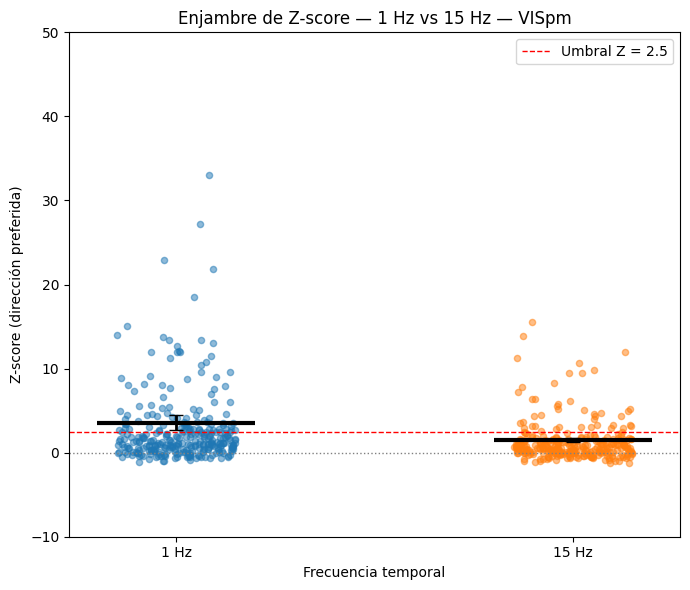

In [ ]:
# ============================================================
# PANEL D · ENJAMBRE DE Z-SCORE POR CONDICIÓN ASIGNADA (1Hz vs 15Hz)
# ============================================================

fig, ax = plt.subplots(figsize=(7, 6))

etiquetas = ["1 Hz", "15 Hz"]
colores = ["C0", "C1"]

for j, (etiqueta, color) in enumerate(zip(etiquetas, colores)):
    valores = z_frecuencia[:, j]
    valores = valores[~np.isnan(valores)]

    rng_jit = np.random.default_rng(100 + j)
    x_jitter = j + rng_jit.uniform(-0.15, 0.15, size=len(valores))

    ax.scatter(x_jitter, valores, s=20, alpha=0.5, color=color, zorder=2)

    promedio = valores.mean()
    sem = valores.std(ddof=1) / np.sqrt(len(valores))

    ax.hlines(promedio, j - 0.2, j + 0.2, linewidth=3, color="black", zorder=3)
    ax.errorbar(j, promedio, yerr=sem, fmt="none", color="black",
                 capsize=5, elinewidth=2, zorder=3)

ax.axhline(criterio_z, linestyle="--", linewidth=1, color="red",
            label=f"Umbral Z = {criterio_z}")
ax.axhline(0, linestyle=":", linewidth=1, color="gray")

ax.set_xticks([0, 1])
ax.set_xticklabels(etiquetas)
ax.set_xlabel("Frecuencia temporal")
ax.set_ylabel("Z-score (dirección preferida)")
ax.set_title("Enjambre de Z-score — 1 Hz vs 15 Hz — VISpm")
ax.legend()

plt.ylim(-10, 50)
plt.tight_layout()
plt.show()

# E

RESPONDEDORES POR RATÓN
Ratón 715093703: 1 Hz = 19/51 (0.373) | 15 Hz = 17/51 (0.333)
Ratón 750749662: 1 Hz = 12/65 (0.185) | 15 Hz = 4/65 (0.062)
Ratón 756029989: 1 Hz = 35/94 (0.372) | 15 Hz = 8/94 (0.085)
Ratón 760345702: 1 Hz = 20/45 (0.444) | 15 Hz = 14/45 (0.311)
Ratón 761418226: 1 Hz = 10/41 (0.244) | 15 Hz = 1/41 (0.024)


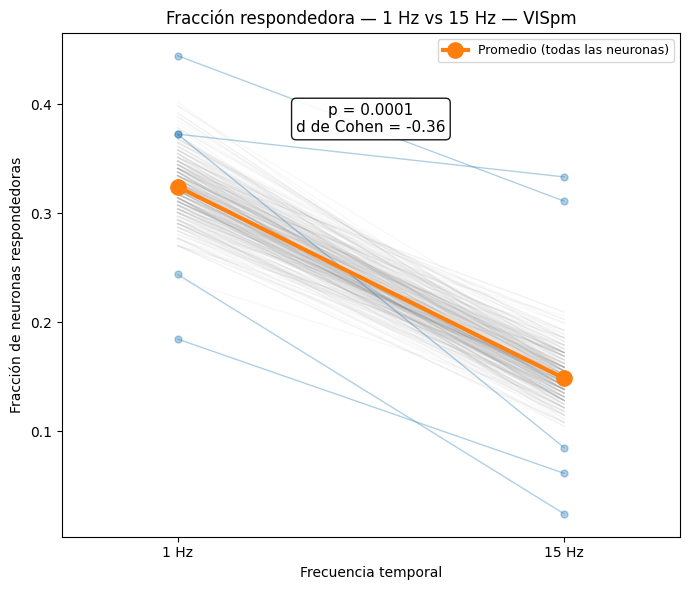

1Hz: 0.324 | 15Hz: 0.149 | p=0.0001 | d=-0.364


In [ ]:
# ============================================================
# E — 1 Hz vs 15 Hz
# FRACCIÓN DE NEURONAS RESPONDEDORAS
# IC 95% BOOTSTRAP + p-VALUE + COHEN'S d
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. PARÁMETROS
# ------------------------------------------------------------

criterio_z = 2.5
n_bootstrap = 5000
n_permutaciones = 10000

rng = np.random.default_rng(12345)

# Frecuencias
frecuencias = [1, 15]

# Ratones
ratones = np.unique(u_raton)

# ------------------------------------------------------------
# 2. FRACCIÓN DE RESPONDEDORES POR RATÓN
# ------------------------------------------------------------

fracciones_1hz = []
fracciones_15hz = []

# Guardamos también las respuestas individuales
respuestas_por_raton = {}

print("==========================================")
print("RESPONDEDORES POR RATÓN")
print("==========================================")

for raton in ratones:

    neuronas = np.where(u_raton == raton)[0]

    # -------------------------
    # 1 Hz
    # -------------------------

    z1 = z_frecuencia[neuronas, 0]

    validos1 = ~np.isnan(z1)

    resp1 = z1[validos1] >= criterio_z

    frac1 = np.mean(resp1)

    # -------------------------
    # 15 Hz
    # -------------------------

    z15 = z_frecuencia[neuronas, 1]

    validos15 = ~np.isnan(z15)

    resp15 = z15[validos15] >= criterio_z

    frac15 = np.mean(resp15)

    # Guardar
    fracciones_1hz.append(frac1)
    fracciones_15hz.append(frac15)

    respuestas_por_raton[raton] = (
        resp1,
        resp15
    )

    print(
        f"Ratón {raton}: "
        f"1 Hz = {np.sum(resp1)}/{len(resp1)} "
        f"({frac1:.3f}) | "
        f"15 Hz = {np.sum(resp15)}/{len(resp15)} "
        f"({frac15:.3f})"
    )

fracciones_1hz = np.array(fracciones_1hz)
fracciones_15hz = np.array(fracciones_15hz)

# ============================================================
# 3. IC 95% BOOTSTRAP PARA CADA PUNTO
# ============================================================

ic_1hz = []
ic_15hz = []

for raton in ratones:

    resp1, resp15 = respuestas_por_raton[raton]

    # --------------------------------------------------------
    # Bootstrap 1 Hz
    # --------------------------------------------------------

    muestras1 = rng.choice(
        resp1,
        size=(n_bootstrap, len(resp1)),
        replace=True
    )

    medias1 = np.mean(
        muestras1,
        axis=1
    )

    ic1 = np.percentile(
        medias1,
        [2.5, 97.5]
    )

    # --------------------------------------------------------
    # Bootstrap 15 Hz
    # --------------------------------------------------------

    muestras15 = rng.choice(
        resp15,
        size=(n_bootstrap, len(resp15)),
        replace=True
    )

    medias15 = np.mean(
        muestras15,
        axis=1
    )

    ic15 = np.percentile(
        medias15,
        [2.5, 97.5]
    )

    ic_1hz.append(ic1)
    ic_15hz.append(ic15)

ic_1hz = np.array(ic_1hz)
ic_15hz = np.array(ic_15hz)

# ============================================================
# 4. P-VALUE — PERMUTACIÓN PAREADA
# ============================================================

# Solo neuronas que tienen Z válido en ambas frecuencias
mask_validas = (
    ~np.isnan(z_frecuencia[:, 0])
    & ~np.isnan(z_frecuencia[:, 1])
)

resp_1 = respondedoras[mask_validas, 0]
resp_15 = respondedoras[mask_validas, 1]

# Diferencia observada
diferencia_observada = (
    np.mean(resp_15)
    - np.mean(resp_1)
)

# Diferencias permutadas
diferencias_perm = np.zeros(
    n_permutaciones
)

for p in range(n_permutaciones):

    intercambiar = (
        rng.random(len(resp_1)) < 0.5
    )

    perm_1 = resp_1.copy()
    perm_15 = resp_15.copy()

    perm_1[intercambiar] = (
        resp_15[intercambiar]
    )

    perm_15[intercambiar] = (
        resp_1[intercambiar]
    )

    diferencias_perm[p] = (
        np.mean(perm_15)
        - np.mean(perm_1)
    )

# p bilateral
p_valor = (
    np.sum(
        np.abs(diferencias_perm)
        >= abs(diferencia_observada)
    ) + 1
) / (
    n_permutaciones + 1
)

# ============================================================
# 5. COHEN'S d — PAREADO
# ============================================================

diferencias_neuronas = (
    resp_15.astype(float)
    - resp_1.astype(float)
)

media_diferencia = np.mean(
    diferencias_neuronas
)

sd_diferencia = np.std(
    diferencias_neuronas,
    ddof=1
)

cohen_d = (
    media_diferencia
    / sd_diferencia
)

# ============================================================
# GRÁFICA E — FRACCIÓN DE NEURONAS RESPONDEDORAS (1Hz vs 15Hz)
# ============================================================

criterio_z = 2.5
ratones = np.unique(u_raton)

# --- Fracción por ratón (para las líneas finas de contexto) ---
fracciones_1hz, fracciones_15hz = [], []
for raton in ratones:
    neuronas = np.where(u_raton == raton)[0]
    f1 = np.nanmean(respondedoras[neuronas, 0])
    f15 = np.nanmean(respondedoras[neuronas, 1])
    fracciones_1hz.append(f1)
    fracciones_15hz.append(f15)
fracciones_1hz = np.array(fracciones_1hz)
fracciones_15hz = np.array(fracciones_15hz)

# --- Solo neuronas válidas en ambas frecuencias, para las pruebas pareadas ---
mask_validas = ~np.isnan(z_frecuencia[:, 0]) & ~np.isnan(z_frecuencia[:, 1])
resp_1 = respondedoras[mask_validas, 0]
resp_15 = respondedoras[mask_validas, 1]

# --- Permutación (p-valor) ---
rng = np.random.default_rng(54321)
n_permutaciones = 10000
diferencia_observada = np.mean(resp_15) - np.mean(resp_1)
diferencias_perm = np.zeros(n_permutaciones)
for p in range(n_permutaciones):
    intercambiar = rng.random(len(resp_1)) < 0.5
    perm_1, perm_15 = resp_1.copy(), resp_15.copy()
    perm_1[intercambiar] = resp_15[intercambiar]
    perm_15[intercambiar] = resp_1[intercambiar]
    diferencias_perm[p] = np.mean(perm_15) - np.mean(perm_1)
p_valor = (np.sum(np.abs(diferencias_perm) >= abs(diferencia_observada)) + 1) / (n_permutaciones + 1)

# --- Cohen's d pareado ---
diferencias_neuronas = resp_15.astype(float) - resp_1.astype(float)
cohen_d = diferencias_neuronas.mean() / diferencias_neuronas.std(ddof=1)

# --- Bootstrap para el fondo visual ---
n_boot_visual = 300
rng2 = np.random.default_rng(7)
trayectorias_1hz, trayectorias_15hz = [], []
for _ in range(n_boot_visual):
    idx_b = rng2.integers(0, len(diferencias_neuronas), len(diferencias_neuronas))
    trayectorias_1hz.append(np.mean(resp_1[idx_b]))
    trayectorias_15hz.append(np.mean(resp_15[idx_b]))

# --- Gráfica ---
plt.figure(figsize=(7, 6))
for t1, t15 in zip(trayectorias_1hz, trayectorias_15hz):
    plt.plot([0, 1], [t1, t15], color="gray", alpha=0.05, linewidth=1, zorder=1)
for f1, f15 in zip(fracciones_1hz, fracciones_15hz):
    plt.plot([0, 1], [f1, f15], color="C0", alpha=0.35, linewidth=1, marker="o", markersize=5, zorder=2)
plt.plot([0, 1], [fraccion_1hz, fraccion_15hz], color="C1", linewidth=3,
          marker="o", markersize=11, zorder=3, label="Promedio (todas las neuronas)")
plt.text(0.5, max(fraccion_1hz, fraccion_15hz) + 0.05,
          f"p = {p_valor:.4f}\nd de Cohen = {cohen_d:.2f}",
          ha="center", fontsize=11, bbox=dict(boxstyle="round", facecolor="white", alpha=0.9))
plt.xticks([0, 1], ["1 Hz", "15 Hz"])
plt.xlabel("Frecuencia temporal")
plt.ylabel("Fracción de neuronas respondedoras")
plt.title("Fracción respondedora — 1 Hz vs 15 Hz — VISpm")
plt.legend(loc="upper right", fontsize=9)
plt.xlim(-0.3, 1.3)
plt.tight_layout()
plt.show()

print(f"1Hz: {fraccion_1hz:.3f} | 15Hz: {fraccion_15hz:.3f} | p={p_valor:.4f} | d={cohen_d:.3f}")